In [1]:
# Author: Jaakko Leppakangas <jaeilepp@student.jyu.fi>
#
# License: BSD (3-clause)

import numpy as np
import neo #주로 신경과학 및 전기생리학(Electrophysiology) 데이터를 다루는 패키지 
import addcopyfighandler
import matplotlib.pyplot as plt

import mne

print(__doc__)

Automatically created module for IPython interactive environment


In [ ]:
%matplotlib qt

Channels marked as bad:
none
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Figure copied: Window title="Figure 1"
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [4]:
# Create arbitary(임의의) data

sfreq = 1000 # Sampling frequency - 1초에 몇 번 sampling 할 것인지
times = np.arange(0, 10, 0.001) # Use 10000 samples(10s) 시간축 생성
#matlab으로 치면 linspace(0, 10, 0.001)과 같다.

sin = np.sin(times * 10) #Multipled by 10 for shorter cycles
cos = np.cos(times * 10)
sinX2 = sin * 2
cosX2 = cos * 2 # 왜 cos sin을 사용하는가? -> EEG, MEG 파형 흉내


# Numpy array of size 4 x 10000. MNE 기본 구조는 (channels, times(samples))
data = np.array([sin, cos, sinX2, cosX2])

#Definition of channel types and names
ch_types = ['mag', 'mag', 'grad', 'grad']
ch_names = ['sin', 'cos', 'sinX2', 'cosX2']

print(data)
print(ch_types)
print(ch_names)


[[ 0.          0.00999983  0.01999867 ... -0.53200348 -0.5235096
  -0.51496337]
 [ 1.          0.99995     0.99980001 ...  0.84674217  0.85201978
   0.85721218]
 [ 0.          0.01999967  0.03999733 ... -1.06400696 -1.0470192
  -1.02992674]
 [ 2.          1.9999      1.99960001 ...  1.69348433  1.70403955
   1.71442437]]
['mag', 'mag', 'grad', 'grad']
['sin', 'cos', 'sinX2', 'cosX2']


In [5]:
# Create an 'info' object from another raw object(생성한 임의의 data) 

# It is also possible to use info from another raw object
# 이미 존재하는 다른 원본 객체의 info를 사용하는 것도 가능(재사용)
#data는 계속 변하지만 info는 대부분 유지됨
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
print(info)

<Info | 7 non-empty values
 bads: []
 ch_names: sin, cos, sinX2, cosX2
 chs: 2 Magnetometers, 2 Gradiometers
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 4
 projs: []
 sfreq: 1000.0 Hz
>


In [6]:
# Create a dummy 'mne.io.RawArray' object

raw = mne.io.RawArray(data, info) # raw 객체(continuous signal) 생성 

# Scaling of the figure.
# For actual EEG/MEG data different scalimg factors should be used

scalings = {'mag': 2, 'grad': 2} # scale: 화면 표시 크기

raw.plot(n_channels=4, scalings=scalings, title='Data from arrays', show=True, block=False)
# block = False: 그래프 띄우고 바로 다음 코드 실행 <-> Block = True plot창을 닫을 때까지 다음 코드 실행 중단
  
# It is also possible to auto-compute scalings
scalings = 'auto' # Could also pass a dictionary with some value == 'auto'
raw.plot(n_channels=4, scalings=scalings, title='Auto-scaled Data from arrays', show=True, block=False)


Creating RawArray with float64 data, n_channels=4, n_times=10000
    Range : 0 ... 9999 =      0.000 ...     9.999 secs
Ready.
Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x169fdf19ee0) at 0x00000169FFF90F00>

In [ ]:
event_id = 1 #This is used to identify the events.
# First column is for the sample number.
events = np.array([[200, 0, event_id],
                   [1200, 0, event_id],
                   [2000, 0, event_id]]) # List of three arbitrary events
#1번 이벤트(arbitrary event) 3개 생성, 200/event 200개, 1200/1200개, 2000(ms)/2000개 sample number에 이벤트 발생

# Here a data set of 700 ms epochs from 2channels is
# created from sin and cos data.
# Any data in shape (n_epochs, n_channels, n_times) can be used.
epochs_data =  np.array([[sin[:700], cos[:700]],
                         [sin[1000:1700], cos[1000:1700]],
                         [sin[1800:2500], cos[1800:2500]]])
# event 이전 200ms, event 이후 500ms 즉, 700ms 길이의 epoch 3개 생성

ch_names = ['sin', 'cos']
ch_types = ['mag', 'mag']
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
#info 업데이트

epochs = mne.EpochsArray(epochs_data, info=info, events=events, event_id={'arbitrary': 1})
# Epochs 객체 생성(epochs_data, info, events, event_id)
picks = mne.pick_types(info, meg=True, eeg=False, misc=False)
# picks: plot할 때 사용할 채널 선택, meg=True Meg 채널만 선택
epochs.plot(picks=picks, scalings='auto', show=True, block=False)
# 시각화할 때 picks로 선택한 채널만 시각화

Not setting metadata
3 matching events found
No baseline correction applied
0 projection items activated


<mne_qt_browser._pg_figure.MNEQtBrowser(0x169fe272a30) at 0x0000016983CEA7C0>

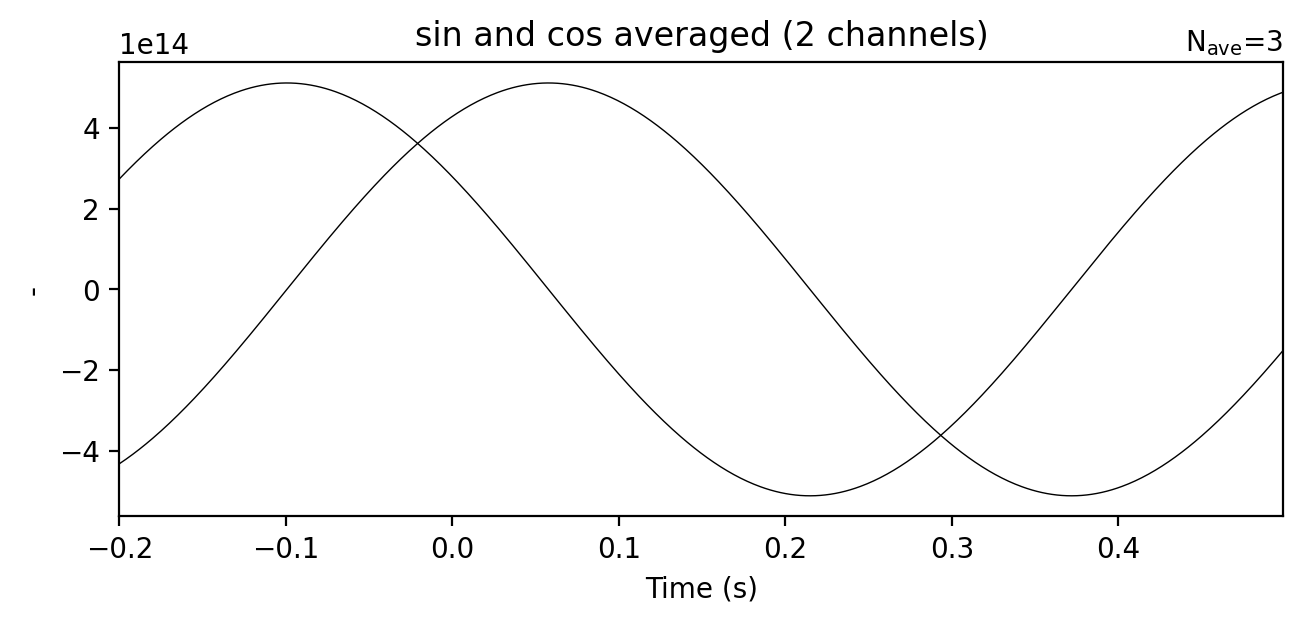

In [10]:
nave = len(epochs_data)  # Number of averaged epochs 평균에 사용된 epoch 수
evoked_data = np.mean(epochs_data, axis=0) # ERP 생성

evokeds = mne.EvokedArray(evoked_data, info=info, tmin=-0.2,
                          comment='Arbitrary', nave=nave)
# Evoked 객체 생성(evoked_data, info, tmin: event 보다 0.2초 전, 
# comment, nave: 평균에 사용된 epochs 수

evokeds.plot(picks=picks, show=True, units={'mag': '-'},
             titles={'mag': 'sin and cos averaged'})

In [12]:
# The events are spaced evenly every 1 second.
duration = 1.
# 1초 단위로 자른다

# create a fixed size events array
# start=0 and stop=None by default
events = mne.make_fixed_length_events(raw, event_id, duration=duration)
# raw 객체를 1초 단위로 자른다, event_id는 1, duration은 1초
print(events)

# for fixed size events no start time before and after event
tmin = 0.
# event 이전 0초
tmax = 0.99  # inclusive tmax, 1 second epochs
# event 이후 약 0.99초까지 -> 정확히 1초 길이가 되어 epoch간 데이터가 겹치지 않도록

# create :class:`Epochs <mne.Epochs>` object
epochs = mne.Epochs(raw, events=events, event_id=event_id, tmin=tmin,
                    tmax=tmax, baseline=None, verbose=True)
#baseline이 없으므로 ERS, ERD 분석 불가
epochs.plot(scalings='auto', block=False)

[[   0    0    1]
 [1000    0    1]
 [2000    0    1]
 [3000    0    1]
 [4000    0    1]
 [5000    0    1]
 [6000    0    1]
 [7000    0    1]
 [8000    0    1]
 [9000    0    1]]
Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 10 events and 991 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 10 events and 991 original time points ...
Using data from preloaded Raw for 10 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using

<mne_qt_browser._pg_figure.MNEQtBrowser(0x169f093b810) at 0x0000016986CEEBC0>

In [15]:
duration = 0.5
# 1-> 0.5 절반으로 줄임
events = mne.make_fixed_length_events(raw, event_id, duration=duration)
print(events)
epochs = mne.Epochs(raw, events=events, tmin=tmin, tmax=tmax, baseline=None,
                    verbose=True)
epochs.plot(scalings='auto', block=False)

[[   0    0    1]
 [ 500    0    1]
 [1000    0    1]
 [1500    0    1]
 [2000    0    1]
 [2500    0    1]
 [3000    0    1]
 [3500    0    1]
 [4000    0    1]
 [4500    0    1]
 [5000    0    1]
 [5500    0    1]
 [6000    0    1]
 [6500    0    1]
 [7000    0    1]
 [7500    0    1]
 [8000    0    1]
 [8500    0    1]
 [9000    0    1]
 [9500    0    1]]
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 20 events and 991 original time points ...
1 bad epochs dropped
Using data from preloaded Raw for 19 events and 991 original time points ...
Using data from preloaded Raw for 19 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 original time points ...
Using data from preloaded Raw for 1 events and 991 or

<mne_qt_browser._pg_figure.MNEQtBrowser(0x169bfaeab70) at 0x0000016986C82E00>

In [ ]:
duration = 0.5
# 1-> 0.5 절반으로 줄임
tmax = 0.49
events = mne.make_fixed_length_events(raw, event_id, duration=duration)
print(events)
epochs = mne.Epochs(raw, events=events, tmin=tmin, tmax=tmax, baseline=None,
                    verbose=True)
epochs.plot(scalings='auto', block=False)

[[   0    0    1]
 [ 500    0    1]
 [1000    0    1]
 [1500    0    1]
 [2000    0    1]
 [2500    0    1]
 [3000    0    1]
 [3500    0    1]
 [4000    0    1]
 [4500    0    1]
 [5000    0    1]
 [5500    0    1]
 [6000    0    1]
 [6500    0    1]
 [7000    0    1]
 [7500    0    1]
 [8000    0    1]
 [8500    0    1]
 [9000    0    1]
 [9500    0    1]]
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 20 events and 491 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 20 events and 491 original time points ...
Using data from preloaded Raw for 20 events and 491 original time points ...
Using data from preloaded Raw for 2 events and 491 original time points ...
Using data from preloaded Raw for 2 events and 491 original time points ...
Using data from preloaded Raw for 2 events and 491 original time points ...
Using data from preloaded Raw for 2 events and 491 or

<mne_qt_browser._pg_figure.MNEQtBrowser(0x1698bc9d920) at 0x0000016985F2F8C0>